In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, fpgrowth

##ĐỌC FILE TỪ THÀNH VIÊN 1
df_encoded = pd.read_csv("food_association_ready.csv")

print("Số sinh viên (transactions):", len(df_encoded))
print("Số item:", len(df_encoded.columns))
display(df_encoded.head())

Số sinh viên (transactions): 125
Số item: 37


,breakfast_Breakfast_No,breakfast_Breakfast_Yes,eating_out_High,eating_out_Low,eating_out_Medium,fruit_day_High,fruit_day_Low,fruit_day_Medium,veggies_day_High,veggies_day_Low,...,greek_food_Medium,indian_food_High,indian_food_Low,indian_food_Medium,thai_food_High,thai_food_Low,thai_food_Medium,ethnic_food_High,ethnic_food_Low,ethnic_food_Medium
0,1,0,0,0,1,1,0,0,1,0,...,0,1,0,0,0,1,0,0,1,0
1,1,0,0,1,0,0,0,1,0,0,...,1,0,0,1,0,1,0,0,0,1
2,1,0,0,1,0,1,0,0,1,0,...,0,1,0,0,1,0,0,1,0,0
3,1,0,0,1,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,0
4,1,0,0,1,0,0,0,1,0,0,...,1,0,1,0,0,0,1,0,0,1


 Kiểm tra dữ liệu đầu vào

 Kiểm tra giá trị thiếu, giá trị ngoài 0/1, tên cột trùng; sau đó đổi 0/1 thành False/True.

 astype(bool) có thể biến giá trị khác 0 (hoặc NaN) thành True, nên **phải kiểm tra trước khi chuyển kiểu**.

 Tránh kết quả support sai do dữ liệu lỗi. Không tự xóa các dòng khảo sát giống nhau: hai sinh viên trả lời giống nhau vẫn là hai transaction hợp lệ.

In [ ]:
# Kiểm tra dữ liệu trước khi chạy Apriori

print("Số ô bị thiếu:", df_encoded.isna().sum().sum())
print("Các giá trị xuất hiện:", pd.unique(df_encoded.to_numpy().ravel()))

if df_encoded.empty:
    print("Lỗi: File không có dữ liệu!")

elif df_encoded.columns.duplicated().any():
    print("Lỗi: Tên cột bị trùng!")

elif df_encoded.isna().sum().sum() > 0:
    print("Lỗi: Dữ liệu có giá trị thiếu!")

elif not df_encoded.isin([0, 1]).all().all():
    print("Lỗi: Dữ liệu phải chỉ chứa 0 và 1!")

else:
    print("Dữ liệu hợp lệ!")

    df_encoded = df_encoded.astype(bool)

    display(df_encoded.head())

Số ô bị thiếu: 0
Các giá trị xuất hiện: [1 0]
Dữ liệu hợp lệ!


,breakfast_Breakfast_No,breakfast_Breakfast_Yes,eating_out_High,eating_out_Low,eating_out_Medium,fruit_day_High,fruit_day_Low,fruit_day_Medium,veggies_day_High,veggies_day_Low,...,greek_food_Medium,indian_food_High,indian_food_Low,indian_food_Medium,thai_food_High,thai_food_Low,thai_food_Medium,ethnic_food_High,ethnic_food_Low,ethnic_food_Medium
0,True,False,False,False,True,True,False,False,True,False,...,False,True,False,False,False,True,False,False,True,False
1,True,False,False,True,False,False,False,True,False,False,...,True,False,False,True,False,True,False,False,False,True
2,True,False,False,True,False,True,False,False,True,False,...,False,True,False,False,True,False,False,True,False,False
3,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,True,False,False,True,False,False
4,True,False,False,True,False,False,False,True,False,False,...,True,False,True,False,False,False,True,False,False,True


THUẬT TOÁN APRIORI MINSUP=0.1

 Tìm các tập item xuất hiện trong ít nhất 10% số sinh viên. use_colnames=True hiển thị tên thuộc tính thay cho mã cột.

 Nếu một tập item không phổ biến thì mọi tập chứa nó cũng không phổ biến. Nhờ vậy thuật toán loại bớt các ứng viên.

Tìm các thói quen hoặc sở thích thường xuất hiện cùng nhau và tạo đầu vào cho phần sinh luật của Thành viên 3.

Thời gian được đo bằng time.perf_counter() đặt ngay trước và sau lời gọi thuật toán.

In [ ]:
from mlxtend.frequent_patterns import apriori

start_time = time.perf_counter()

frequent_itemsets_ap = apriori(
    df_encoded,
    min_support=0.1,
    use_colnames=True
)

apriori_time = time.perf_counter() - start_time

print("KẾT QUẢ Thuật Toán")
print("Min Support:", 0.1)
print("Số frequent itemsets:", len(frequent_itemsets_ap))
print("Thời gian chạy:", round(apriori_time, 6), "giây")

display(frequent_itemsets_ap)

KẾT QUẢ Thuật Toán
Min Support: 0.1
Số frequent itemsets: 2558
Thời gian chạy: 0.040914 giây


,support,itemsets
0,0.888,(breakfast_Breakfast_No)
1,0.112,(breakfast_Breakfast_Yes)
2,0.608,(eating_out_Low)
3,0.296,(eating_out_Medium)
4,0.504,(fruit_day_High)
...,...,...
2553,0.112,"(italian_food_High, ethnic_food_High, fruit_da..."
2554,0.112,"(italian_food_High, ethnic_food_High, thai_foo..."
2555,0.120,"(italian_food_High, indian_food_High, eating_o..."
2556,0.112,"(italian_food_High, indian_food_High, breakfas..."


Thuật toán FP-Growth cùng MinSup sử dụng cùng minsup=0.1

In [ ]:
minsup = 0.1
start = time.perf_counter()
frequent_itemsets_fp = fpgrowth(df_encoded, min_support=minsup, use_colnames=True)
fpgrowth_time = time.perf_counter() - start

print("FP-Growth - số tập phổ biến:", len(frequent_itemsets_fp))
print("Thời gian (giây):", round(fpgrowth_time, 6))
display(frequent_itemsets_fp.sort_values("support", ascending=False).head(20))

FP-Growth - số tập phổ biến: 2558
Thời gian (giây): 0.839299


,support,itemsets
0,0.888,(breakfast_Breakfast_No)
1,0.800,(italian_food_High)
34,0.720,"(breakfast_Breakfast_No, italian_food_High)"
12,0.616,(healthy_feeling_High)
13,0.608,(eating_out_Low)
807,0.560,"(breakfast_Breakfast_No, healthy_feeling_High)"
810,0.536,"(eating_out_Low, breakfast_Breakfast_No)"
14,0.536,(cook_Medium)
15,0.504,(nutritional_check_Medium)
16,0.504,(calories_day_Medium)


THUẬT TOÁN IT _TREE CHO NGƯỠNG MINSUP=0.1

In [ ]:
def it_tree_mining(df, minsup=0.1):
    n = len(df)
    if n == 0:
        raise ValueError("Dữ liệu rỗng")

    # Lấy các giao dịch chứa từng item
    items = [
        (col, set(df.index[df[col]]))
        for col in df.columns
    ]

    results = []

    # Tìm các tập phổ biến bằng cách giao TID
    def search(prefix, items):
        for i, (name, tids) in enumerate(items):
            if len(tids) / n < minsup:
                continue

            new_set = prefix | {name}
            results.append((len(tids) / n, frozenset(new_set)))

            next_items = [
                (name2, tids & tids2)
                for name2, tids2 in items[i + 1:]
            ]

            search(new_set, next_items)

    search(set(), items)

    return pd.DataFrame(results, columns=["support", "itemsets"])


# RUN IT-Tree
start = time.perf_counter()

frequent_itemsets_it = it_tree_mining(df_encoded, 0.1)

it_time = time.perf_counter() - start

print("Số tập phổ biến:", len(frequent_itemsets_it))
print("Thời gian:", round(it_time, 6), "giây")

display(frequent_itemsets_it.head(20))

KIỂM TRA 3 THUẬT TOÁN

In [ ]:
# KIỂM TRA KẾT QUẢ 3 THUẬT TOÁN

# Lấy các tập phổ biến
ap = set(frequent_itemsets_ap["itemsets"])
fp = set(frequent_itemsets_fp["itemsets"])
it = set(frequent_itemsets_it["itemsets"])

# In số lượng tập phổ biến
print("Apriori:", len(ap))
print("FP-Growth:", len(fp))
print("IT-Tree:", len(it))

# So sánh kết quả
if ap == fp == it:
    print("3 thuật toán cho cùng tập phổ biến")
else:
    print("3 thuật toán cho kết quả khác nhau")

Apriori: 2558
FP-Growth: 2558
IT-Tree: 2558
3 thuật toán cho cùng tập phổ biến


Thực nghiệm Trục B: MinSup và thời gian chạy
 Cho cả ba thuật toán chạy với các mức MinSup 5%, 10%, 15%, 20%, 25%, 30%; lưu số tập phổ biến và thời gian.

MinSup thấp thường giữ nhiều tập phổ biến hơn.

Đo thời gian ở nhiều ngưỡng cho thấy thuật toán phản ứng thế nào khi độ khó thay đổi.

Có bảng và biểu đồ đúng yêu cầu Trục B. Mỗi cấu hình được chạy 3 lần và lấy trung vị để hạn chế dao động thời gian trên Colab;

Đồng thời do dữ liệu nhỏ nên thời gian có thể rất ngắn và không ổn định sau mỗi lần chạy.

In [ ]:
# THỰC NGHIỆM MINSUP VÀ THỜI GIAN CHẠY

minsup_values = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
results = []

for ms in minsup_values:

    # Apriori
    time_ap = []
    for i in range(3):
        start = time.perf_counter()
        ap = apriori(df_encoded, min_support=ms, use_colnames=True)
        time_ap.append(time.perf_counter() - start)

    # FP-Growth
    time_fp = []
    for i in range(3):
        start = time.perf_counter()
        fp = fpgrowth(df_encoded, min_support=ms, use_colnames=True)
        time_fp.append(time.perf_counter() - start)

    # IT-Tree
    time_it = []
    for i in range(3):
        start = time.perf_counter()
        it = it_tree_mining(df_encoded, ms)
        time_it.append(time.perf_counter() - start)

    # Lưu kết quả
    results.append({
        "MinSup": ms,
        "Apriori_Time": sorted(time_ap)[1],
        "FP_Growth_Time": sorted(time_fp)[1],
        "IT_Tree_Time": sorted(time_it)[1],
        "Apriori_Itemsets": len(ap),
        "FP_Growth_Itemsets": len(fp),
        "IT_Tree_Itemsets": len(it)
    })

experiment_df = pd.DataFrame(results)

display(experiment_df)

,MinSup,Apriori_Time,FP_Growth_Time,IT_Tree_Time,Apriori_Itemsets,FP_Growth_Itemsets,IT_Tree_Itemsets
0,0.05,0.130633,4.383259,0.050174,11618,11618,11618
1,0.10,0.030073,0.801108,0.017479,2558,2558,2558
2,0.15,0.011992,0.354598,0.011755,873,873,873
3,0.20,0.011197,0.192495,0.007918,373,373,373
4,0.25,0.009953,0.102998,0.005745,156,156,156
5,0.30,0.006093,0.049242,0.004391,90,90,90


BIỂU ĐỒ THỰC NGHIỆM


Biểu đồ MinSup và số tập phổ biến

Giải thích :Cả 3 thuật toán đều có cùng số tập phổ biến nên 3 đường trùng nhau

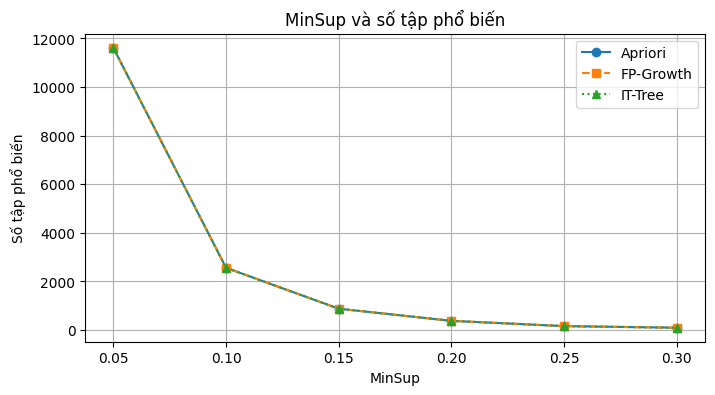

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(experiment_df["MinSup"],
         experiment_df["Apriori_Itemsets"],
         marker="o", label="Apriori")

plt.plot(experiment_df["MinSup"],
         experiment_df["FP_Growth_Itemsets"],
         marker="s", linestyle="--", label="FP-Growth")

plt.plot(experiment_df["MinSup"],
         experiment_df["IT_Tree_Itemsets"],
         marker="^", linestyle=":", label="IT-Tree")

plt.xlabel("MinSup")
plt.ylabel("Số tập phổ biến")
plt.title("MinSup và số tập phổ biến")
plt.legend()
plt.grid(True)
plt.show()


Biểu đồ MinSup và thời gian chạy

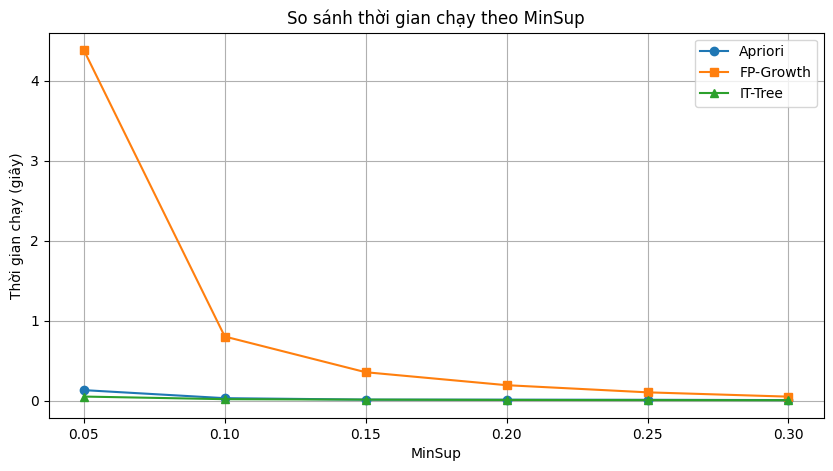

BẢNG THỜI GIAN CHẠY THEO TỪNG MINSUP


,MinSup,Apriori_Time,FP_Growth_Time,IT_Tree_Time
0,0.05,0.1306,4.3833,0.0502
1,0.10,0.0301,0.8011,0.0175
2,0.15,0.0120,0.3546,0.0118
3,0.20,0.0112,0.1925,0.0079
4,0.25,0.0100,0.1030,0.0057
5,0.30,0.0061,0.0492,0.0044


In [30]:
# BIỂU ĐỒ THỜI GIAN CHẠY CỦA 3 THUẬT TOÁN

plt.figure(figsize=(10, 5))

plt.plot(experiment_df["MinSup"],
         experiment_df["Apriori_Time"],
         marker="o", label="Apriori")

plt.plot(experiment_df["MinSup"],
         experiment_df["FP_Growth_Time"],
         marker="s", label="FP-Growth")

plt.plot(experiment_df["MinSup"],
         experiment_df["IT_Tree_Time"],
         marker="^", label="IT-Tree")

plt.xlabel("MinSup")
plt.ylabel("Thời gian chạy (giây)")
plt.title("So sánh thời gian chạy theo MinSup")
plt.legend()
plt.grid(True)
plt.show()

# BẢNG THỜI GIAN CHẠY (4 CHỮ SỐ THẬP PHÂN)

print("BẢNG THỜI GIAN CHẠY THEO TỪNG MINSUP")

bang_thoi_gian = experiment_df[
    ["MinSup", "Apriori_Time",
     "FP_Growth_Time", "IT_Tree_Time"]
]

display(bang_thoi_gian.round(4))

## 9. Hàm khai phá để bàn giao cho Thành viên 3
**Làm gì?** `mine_itemsets(minsup)` nhận ngưỡng và trả về các tập phổ biến bằng Apriori.

**Tại sao?** Thành viên 3 có thể lấy kết quả này để sinh luật theo `minconf` mà không phải viết lại phần khai phá.

**Lợi ích:** Phân chia nhiệm vụ rõ ràng và dễ ghép chung trong một notebook. **Chưa định nghĩa `mine_rules(minsup, minconf)` giả**, vì hàm đó phải trả về luật thực sự và cần phần `generate_rules(...)` của Thành viên 3. Theo bảng phân công, Giáo sư có trách nhiệm phối hợp demo hàm ghép sau khi TV3 hoàn thiện phần sinh luật.

In [ ]:
# HÀM KHAI PHÁ TẬP PHỔ BIẾN

def mine_itemsets(minsup):

    # Chạy Apriori với ngưỡng MinSup
    frequent_itemsets = apriori(
        df_encoded,
        min_support=minsup,
        use_colnames=True
    )

    return frequent_itemsets


# Kiểm tra hàm
itemsets_demo = mine_itemsets(0.1)

print("MinSup: 0.1")
print("Số tập phổ biến:", len(itemsets_demo))

display(itemsets_demo.head(10))

LƯU FILE KẾT QUẢ TỪNG THUẬT TOÁN VÀ BIỂU ĐỒ

In [ ]:
frequent_itemsets_ap.to_csv("frequent_itemsets_apriori.csv", index=False)
frequent_itemsets_fp.to_csv("frequent_itemsets_fpgrowth.csv", index=False)
frequent_itemsets_it.to_csv("frequent_itemsets_ittree.csv", index=False)
experiment_df.to_csv("minsup_experiment_3_algorithms.csv", index=False)
print("Đã lưu 4 file CSV kết quả.")


Nguồn tham khảo : [mlxtend Apriori](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/), [mlxtend FP-Growth](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/).